# Convert Faust to JAX in DawDreamer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](http://colab.research.google.com/github/DBraun/DawDreamer/blob/main/examples/Faust_to_JAX/Faust_to_JAX.ipynb)

[Faust](https://faust.grame.fr/) (**F**unctional **AU**dio **ST**ream) is a functional programming language for sound synthesis and audio processing with a strong focus on the design of synthesizers, musical instruments, and audio effects. Faust targets high-performance signal processing applications and audio plug-ins for a variety of platforms and standards.

The core component of Faust is its compiler. It enables the translation of any Faust digital signal processing (DSP) code to a wide range of non-domain specific languages such as C++, C, LLVM bit code, WebAssembly, Rust, Julia and more. In this Python notebook, we'll use [DawDreamer](https://github.com/DBraun/DawDreamer/) to translate Faust into [JAX](https://jax.readthedocs.io/)/[Flax](https://flax.readthedocs.io/) code. We'll  build several Flax examples:
* Optimizing the cutoff frequency of a low-pass filter, assuming it is held constant
* Optimizing the cutoff frequency of a low-pass filter, allowing for automation
* Making a differentiable subtractive synthesizer
* Making a differentiable polyphonic wavetable synthesizer *whose wavetables are learnable*

## CPU versus GPU/TPU

**Pick your Runtime Hardware Accelerator.** If on Google Colab, go to "Runtime>Change Runtime Type". Otherwise, you can do it programmatically once jax is imported:

```python
import jax
default_device = 'cpu' # or 'gpu'
jax.config.update('jax_platform _name',default_devicee)
```

You may want to pick CPU if your batch size is small. However, for larger batch sizes, the benefit of GPU parallelism will outweigh the worse single-item performance of a GPU relative to a CPU. For example, a CPU could produce 1 item of L-seconds of audio in 1 second. To get to 10 items, the CPU would take 10 seconds. However, in those same 10 seconds, the GPU might produce 20 equivalent items. The CPU took 1 second for its small batch, and the GPU took 10 seconds, but the GPU is twice as productive thanks to parallelism.

## Install and setup

Let's install the requirements:

In [1]:
if 'google.colab' in str(get_ipython()):
    !pip install numpy scipy librosa jax flax optax

In [2]:
try:
    import dawdreamer
except ModuleNotFoundError:
    !pip install dawdreamer

And importing the libraries:

In [3]:
from functools import partial
import itertools
from pathlib import Path
import os

import jax
default_device = 'cpu'
jax.config.update('jax_platform_name', default_device)
import jax.numpy as jnp
from jax import random

from flax import linen as nn
from flax.training import train_state  # Useful dataclass to keep train state
from flax.core.frozen_dict import unfreeze
import optax

from dawdreamer.faust import createLibContext, destroyLibContext, FaustContext
from dawdreamer.faust.box import *

from tqdm.notebook import tqdm
import numpy as np
from scipy.io import wavfile
import librosa
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from IPython.display import HTML
from IPython.display import Audio
import IPython.display as ipd

Define some constants and utilities:

In [4]:
SAMPLE_RATE = 44100

def show_audio(data, autoplay=False):
    if abs(data).max() > 1.:
        data /= abs(data).max()
    
    ipd.display(Audio(data=data, rate=SAMPLE_RATE, normalize=False, autoplay=autoplay))

## Faust Basics

If you're fluent in Faust, you can skip this block:

Let's write some Faust code for a low-pass filter with a cutoff frequency as a user interface slider:

```faust
import("stdfaust.lib");
cutoff = hslider("cutoff", 440., 20., 20000., .01);
process = fi.lowpass(1, cutoff);
```

We define a cutoff parameter initialized at 440, with a range of 20 to 20000., with a step size of .01 (The step size doesn't matter for JAX).

The code above uses `fi.lowpass` from the [Faust Libraries](https://faustlibraries.grame.fr/libs/filters/#filowpass). Specifically, `fi.lowpass` takes three arguments: 
* `N`: the filter order (number of poles) (non-negative, constant numerical expression)
* `fc`: the filter cutoff in Hz
* `s`: the signal which will be filtered

If we specify only two arguments by writing `fi.lowpass(1, 440.)`, the result is a [partial application](https://en.wikipedia.org/wiki/Partial_application) which takes the right-most arguments that weren't specified, in this case an input signal.

Thus, `fi.lowpass(1, 440.)` is equivalent to `_ : fi.lowpass(1, 440.) : _`. This is a single "wire" operator `_` sequenced into a filter, outputting a single "wire" operator `_`.

We can replace `440.` with a UI slider:
```faust
import("stdfaust.lib");
cutoff = hslider("cutoff", 440., 20., 20000., .01);
process = fi.lowpass(1, cutoff);
```

Note that the code above is equivalent to the code below in which we move `cutoff` outside of the lowpass function:
```faust
import("stdfaust.lib");
cutoff = hslider("cutoff", 440., 20., 20000., .01);
process = cutoff, _ : fi.lowpass(1);
```
or even
```faust
import("stdfaust.lib");
cutoff = hslider("cutoff", 440., 20., 20000., .01);
myFilter(x) = cutoff, x : fi.lowpass(1);
process = myFilter;
```

Another design strategy would be to put functions such as `cutoff` in a local scope using the [with](https://faustdoc.grame.fr/manual/syntax/#with-expression) expression:
```faust
import("stdfaust.lib");
myFilter = fi.lowpass(1, cutoff)
with {
    cutoff = hslider("cutoff", 440., 20., 20000., .01);
};
process = myFilter;
```

## Exporting Code

Let's proceed with the following Faust code:

In [5]:
faust_code = """
import("stdfaust.lib");
cutoff = hslider("cutoff", 440., 20., 20000., .01);
process = fi.lowpass(1, cutoff);
"""

To convert it to Faust with DawDreamer, we must first convert it to a Box. When working with the Box API, it is necessary to execute box-related functions inside a `FaustContext()`, or bookmarked between `createLibContext()` and `destroyLibContext()`:

In [6]:
with FaustContext():
    box = boxFromDSP(faust_code)

    assert box.inputs == 1
    assert box.outputs == 1
    
    # Now we can convert it to C++ and specify a C++ class name MyDSP:
    module_name = "MyDSP"
    cpp_code = boxToSource(box, 'cpp', module_name)

# Or alternatively
createLibContext()
box = boxFromDSP(faust_code)
cpp_code = boxToSource(box, 'cpp', "MyDSP")
print(cpp_code)
destroyLibContext()

/* ------------------------------------------------------------
name: "dawdreamer"
Code generated with Faust 2.69.3 (https://faust.grame.fr)
Compilation options: -lang cpp -ct 1 -cn MyDSP -es 1 -mcd 16 -single -ftz 0
------------------------------------------------------------ */

#ifndef  __MyDSP_H__
#define  __MyDSP_H__

#ifndef FAUSTFLOAT
#define FAUSTFLOAT float
#endif 

#include <algorithm>
#include <cmath>
#include <cstdint>
#include <math.h>

#ifndef FAUSTCLASS 
#define FAUSTCLASS MyDSP
#endif

#ifdef __APPLE__ 
#define exp10f __exp10f
#define exp10 __exp10
#endif

#if defined(_WIN32)
#define RESTRICT __restrict
#else
#define RESTRICT __restrict__
#endif


class MyDSP : public dsp {
	
 private:
	
	float fVec0[2];
	FAUSTFLOAT fHslider0;
	int fSampleRate;
	float fConst0;
	float fRec0[2];
	
 public:
	MyDSP() {}

	void metadata(Meta* m) { 
		m->declare("compile_options", "-lang cpp -ct 1 -cn MyDSP -es 1 -mcd 16 -single -ftz 0");
		m->declare("name", "dawdreamer");
	}

	virtual int g

That generated C++ code. You should check out the `virtual void compute` method. Next, let's convert the box to JAX.

In [7]:
with FaustContext():
    box = boxFromDSP(faust_code)

    assert box.inputs == 1
    assert box.outputs == 1
        
    module_name = "MyDSP"
    jax_code = boxToSource(box, 'jax', module_name, ['-a', 'jax/minimal.py'])
    print(jax_code)

# ************************************************************************
# FAUST Architecture File
# Copyright (C) 2022 GRAME, Centre National de Creation Musicale
# ---------------------------------------------------------------------

# This is sample code. This file is provided as an example of minimal
# FAUST architecture file. Redistribution and use in source and binary
# forms, with or without modification, in part or in full are permitted.
# In particular you can create a derived work of this FAUST architecture
# and distribute that work under terms of your choice.

# This sample code is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.
# ************************************************************************

import json
import re
import dataclasses
from pathlib import Path
from typing import List

import numpy as np
import librosa
import jax
import jax.numpy

In C++, the `compute` method did most of the signal processing work, but in JAX, the `tick` function does the work.

Note that if you have Faust installed on your computer, you don't need DawDreamer to convert Faust to JAX or any of the other backends. Put your Faust code in a file such as `faust_code.dsp`. Then in a Terminal/cmd window, run:

```bash
faust faust_code.dsp -lang jax -a jax/minimal.py -cn MyDSP -o my_jax_code.py
```

Because we're using the JAX backend (`-lang jax`), we can specify an architecture file [-a jax/minimal.py](https://github.com/grame-cncm/faust/blob/master-dev/architecture/jax/minimal.py). This architecture file is where we define many of the methods of the Flax module which don't depend on the generated DSP code. For example, a method for reading audio files from the filesystem is independent of the generated DSP code which uses the audio file. Read more about architecture files [here](https://faustdoc.grame.fr/manual/architectures/).

The command-line script above produces a python file named `my_jax_code.py`.

You can now run `python my_jax_code.py --help` to see how to use it. Inside `my_jax_code.py`, there is a [Module](https://flax.readthedocs.io/en/latest/api_reference/flax.linen/module.html) named "MyDSP". You might want to use it in some other file by doing
```python
from my_jax_code import MyDSP
dsp = MyDSP(sample_rate=44100)
# and use it more...
```

### Making a mini-library

One can use the technique above to make a collection of reusable modules just like some of the existing PyTorch libraries about DDSP. For example, you could do

```bash
faust compressor.dsp -lang jax -a jax/minimal.py -cn Compressor -o compressor.py
faust distortion.dsp -lang jax -a jax/minimal.py -cn Distortion -o distortion.py
faust stereo_width.dsp -lang jax -a jax/minimal.py -cn StereoWidth -o stereo_width.py
```

Then in some other Python file, import all the classes and use them:
```python
from compressor import Compressor
from distortion import Distortion
from stereo_width import StereoWidth
```

### Skipping text-files

In certain situations, we don't want to bother saving our JAX code to the file system. We just want to generate it and immediately execute it. Of course, executing Python code that you haven't written yourself or examined yourself is **dangerous**. Only do this if you trust the person who made the Faust-JAX code! We'll execute the generated JAX code using python's [exec](https://docs.python.org/3/library/functions.html#exec) and then fetch the class. There is a lot of complicated JAX-specific code in here, especially [vmap](https://flax.readthedocs.io/en/latest/api_reference/flax.linen/_autosummary/flax.linen.vmap.html). Don't worry if it doesn't make sense the first time you read it. Just come back later to read it again.

In [8]:
def faust2jax(faust_code: str):
    """
    Convert faust code into a batched JAX model and a single-item inference function.

    Inputs:
    * faust_code: string of faust code.
    """
    
    module_name = "MyDSP"
    with FaustContext():
    
      box = boxFromDSP(faust_code)
      
      jax_code = boxToSource(box, 'jax', module_name, ['-a', 'jax/minimal.py'])
    
    custom_globals = {}

    exec(jax_code, custom_globals)  # security risk!

    MyDSP = custom_globals[module_name]
    # MyDSP is now a class definition which can be instantiated or subclassed.

    """
    In our vmap code, we specify `in_axes=(0, None)` to batch along `x` but not along `T`.
    In other words, the `x` argument will be a batch, but our `T` will remain a simple integer (not a batch of integers)
    We choose `variable_axes={'params': None, 'intermediates': 0}` in order to share parameters among the batch and continue to sow intermediate vars
    We choose `split_rngs={'params': False}` to use the same random number generator for each item in the batch.
    """
    MyDSP = nn.vmap(MyDSP, in_axes=(0, None), variable_axes={'params': None, 'intermediates': 0}, split_rngs={'params': False})

    # Now we can create a model that handles batches of input.
    model_batch = MyDSP(sample_rate=SAMPLE_RATE)

    # let's jit compile the model's `apply` method    
    jit_inference_fn = jax.jit(partial(model_batch.apply, mutable='intermediates'), static_argnums=[2])

    # We jitted the model's "apply" function, which is of the form `apply(params, x, T)`. 
    # T (the number of samples of the output) is a constant, so we specified static_argnums=[2].
    
    # We specify mutable='intermediates' to access intermediate variables, which are
    # human-interpretable.
    # Our architecture file normalized all of the parameters to be between -1 and 1.
    # During a forward pass, the parameters are remapped to their original ranges
    # and stored as intermediate variables via the `sow` method.

    return model_batch, jit_inference_fn

hidden_model, jit_hidden = faust2jax(faust_code)

## Pseudo Random Numbers in JAX

Next, you may want to read a little about JAX's [PRNG](https://jax.readthedocs.io/en/latest/jax-101/05-random-numbers.html).

The important idea is to start with a `PRNGKey`. Each time we need to use it, we split it and use the `subkey` instead. In the process, we overwrite the `key`, and the process can repeat.
```python
seed = 42
key = random.PRNGKey(seed)
key, subkey = random.split(key)
noise1 = random.uniform(subkey, shape=(100,100))
key, subkey = random.split(key)
noise2 = random.uniform(subkey, shape=(100,100))
key, subkey = random.split(key)
noise3 = random.uniform(subkey, shape=(100,100))
```

## Inference
Let's demonstrate how to use the model on a batch.

In [9]:
# T is the number of audio samples of input and output
T = int(SAMPLE_RATE*1.0)  # 1 second of audio

batch_size = 8

# The middle dimension is the number of channels of input
input_shape = (batch_size, hidden_model.getNumInputs(), T)

key = random.PRNGKey(42)

key, subkey = random.split(key)
noises = random.uniform(subkey, shape=input_shape, minval=-1, maxval=1)

key, subkey = random.split(key)
params = hidden_model.init({'params': subkey}, noises, T)

print('normalized params: ', params)

audio, mod_vars = jit_hidden(params, noises, T)
print('un-normalized params: ', mod_vars['intermediates'])

print('input audio (LOUD!!):')
show_audio(np.array(noises[0]))

print('output audio (less loud):')
show_audio(np.array(audio[0]))

normalized params:  {'params': {'_dawdreamer/cutoff': Array(-0.957958, dtype=float32)}}
un-normalized params:  {'dawdreamer/cutoff': (Array([439.99976, 439.99976, 439.99976, 439.99976, 439.99976, 439.99976,
       439.99976, 439.99976], dtype=float32),)}
input audio (LOUD!!):


output audio (less loud):


### Pathnames

First, look at the `un-normalized` parameters above where you'll see `dawdreamer/cutoff`. We defined our Faust `cutoff` parameter as `hslider("cutoff", 440., 20., 20000., .01)`. Faust uses [labels as pathnames](https://faustdoc.grame.fr/manual/syntax/#labels-as-pathnames), kind of like a filesystem. We didn't define a root level name of our Faust code (such as `declare name "foo";`), so the root defaults to `dawdreamer`. Therefore `dawdreamer/cutoff` is the full path. If your Faust code involves [groups](https://faustdoc.grame.fr/manual/syntax/#hgroup-primitive) and other [dynamic syntax](https://faustdoc.grame.fr/manual/syntax/#labels-as-pathnames:~:text=of%20attach.-,Variable%20Parts%20of%20a%20Label,-Labels%20can%20contain) such as `hgroup("effect", hslider("cutoff %i", 440., 20., 20000., .01))`, then the path could be `effect/cutoff 1` and so on.

### Normalization

We normalize parameters in order to fix an issue related to the "condition number" of the module we've created. Look at the `normalized params` containing `_dawdreamer/cutoff`. Normalized parameters are preceded with an underscore so JAX can distinguish them from the un-normalized parameters. All normalized parameters are constrained to -1. and 1. Our Faust `cutoff` parameter has the range [20., 20000], so 440 gets remapped fairly close to -1. During the JAX `__call__`, the parameter gets remapped to its original range [20., 20000]. During training, this trick helps us use similar learning rates regardless of the range of our parameters. Consider how the range of a cutoff frequency [20., 20000] measured in Hz is very different from the range of a gain slider [-80, 0] measured in decibels. You can further customize the normalization by applying a scale such as `hslider("cutoff[scale:exp], 440., 20., 20000., .01)`. Check the [architecture file](https://github.com/grame-cncm/faust/blob/master-dev/architecture/jax/minimal.py) for more details. 

### Intermediate variables

Fortunately, we can look at `un-normalized params` above to inspect the human-interpretable value of the parameter, which is approximately 440.0. For more information, read the Flax docs about [intermediate variables](https://flax.readthedocs.io/en/latest/guides/extracting_intermediates.html). If you'd like to normalize parameters differently, feel free to subclass the generated class or contribute to the [architecture file](https://github.com/grame-cncm/faust/blob/master-dev/architecture/jax/minimal.py).

## Training

We'll use our previously created batched model to create a dataset of `(x,y)` pairs of noise and noise low-pass filtered at 440 Hz. Then we'll create a new version of our batched model **with the filter cutoff initialized at 10,000 Hz**. We'll use gradient descent to optimize this second model until it achieves an L1 time-domain loss near zero, and the hidden cutoff parameter of 440 Hz is found.

In [10]:
# Repeat the code much earlier, except create a model whose cutoff is 10,000 Hz.
init_cutoff = 10000 #@param {type: 'number'}
faust_code = f"""
import("stdfaust.lib");
cutoff = hslider("cutoff", {init_cutoff}, 20., 20000., .01);
process = fi.lowpass(1, cutoff);
"""

train_model, jit_train_inference = faust2jax(faust_code)

batch_size = 2 #@param {type: 'integer'}
input_shape = (batch_size, train_model.getNumInputs(), T)

# Create some noises that will serve as our validation dataset
key, subkey = random.split(key)
noises = random.uniform(subkey, shape=input_shape, minval=-1, maxval=1)

key, subkey = random.split(key)
hidden_params = hidden_model.init({'params': subkey}, jnp.zeros_like(noises), T)['params']
key, subkey = random.split(key)
train_params = train_model.init({'params': subkey}, jnp.zeros_like(noises), T)['params']

print('hidden params:', hidden_params)
print('train params:', train_params)

learning_rate = 2e-4 #@param {type: 'number'}
momentum = 0.9 #@param {type: 'number'}

# Create Train state
tx = optax.sgd(learning_rate, momentum)
state = train_state.TrainState.create(apply_fn=train_model.apply, params=train_params, tx=tx)

@jax.jit
def train_step(state, x, y):
    """Train for a single step."""
    
    def loss_fn(params):
        pred = train_model.apply({'params': params}, x, T)
        # L1 time-domain loss
        loss = (jnp.abs(pred - y)).mean()
        return loss, pred
    
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
    (loss, pred), grads = grad_fn(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss

losses = []
cutoffs = []

train_steps = 3000
train_steps_per_eval = 100
pbar = tqdm(range(train_steps))

for n in pbar:
    # Generate a batch of inputs using our hidden parameters (440 Hz cutoff)
    key, subkey = random.split(key)
    x = random.uniform(subkey, shape=input_shape, minval=-1, maxval=1)
    y, _ = jit_hidden({'params': hidden_params}, x, T)
    
    state, loss = train_step(state, x, y)
        
    if n % train_steps_per_eval == 0:
        # jit_train_inference accepts a batch of one item.
        audio, mod_vars = jit_train_inference({'params': state.params}, noises, T)
        cutoff = np.array(mod_vars['intermediates']['dawdreamer/cutoff'])
        # the cutoff above is a batch of predicted cutoff values, so we'll take the mean
        cutoff = cutoff.mean()
        losses.append(loss)
        cutoffs.append(cutoff)
        pbar.set_description(f"cutoff: {cutoff}")

print('Done!')

hidden params: {'_dawdreamer/cutoff': Array(-0.957958, dtype=float32)}
train params: {'_dawdreamer/cutoff': Array(-0.001001, dtype=float32)}


  0%|          | 0/3000 [00:00<?, ?it/s]

Done!


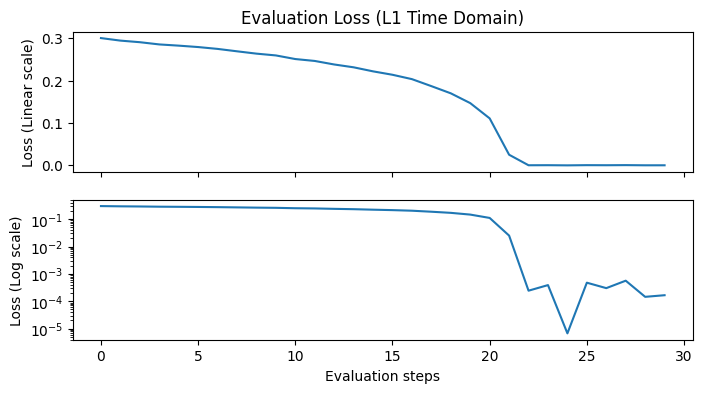

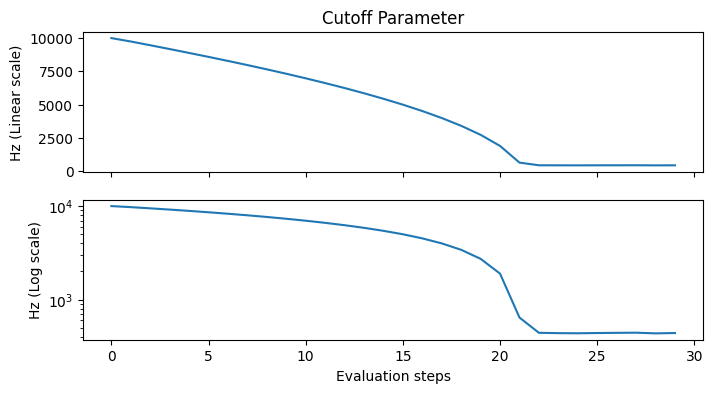

In [11]:
plt.figure(figsize =(8, 4))

ax1 = plt.subplot(211)
ax1.plot(losses)
ax1.set_title("Evaluation Loss (L1 Time Domain)")
ax1.set_ylabel("Loss (Linear scale)")
plt.tick_params('x', labelbottom=False)

ax2 = plt.subplot(212, sharex=ax1)
ax2.plot(losses)
ax2.set_ylabel("Loss (Log scale)")
ax2.set_xlabel("Evaluation steps")
ax2.set_yscale('log')

plt.show()

plt.figure(figsize =(8, 4))

ax1 = plt.subplot(211)
ax1.plot(cutoffs)
ax1.set_title("Cutoff Parameter")
ax1.set_ylabel("Hz (Linear scale)")
plt.tick_params('x', labelbottom=False)

ax2 = plt.subplot(212, sharex=ax1)
ax2.plot(cutoffs)
ax2.set_ylabel("Hz (Log scale)")
ax2.set_xlabel("Evaluation steps")
ax2.set_yscale('log')

plt.show()

It converged to 440 Hz! By the way, [optax](https://optax.readthedocs.io/en/latest/api.html) offers many more optimizers beyond the stochastic-gradient-descent one we used.




## Loss Landscape

For a fixed input example, we can hold all parameters constant except for one which will vary. We'll plot this varying parameter along the x-axis. On the y-axis, we'll plot the loss between the ground truth output and the predicted output. Because our model only consists of one parameter, we can plot our earlier loss time-series as a scatterplot over these graphs.

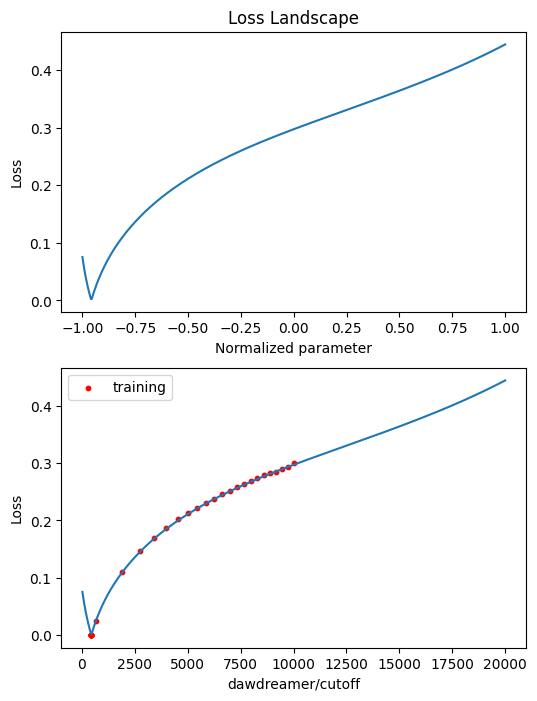

In [12]:
# Pick a single example
x = noises[0:1]
y = hidden_model.apply({'params': hidden_params}, x, T)

# Pick the first param to be the varying parameter.
# There happens to only be one parameter.
param_name = list(hidden_params.keys())[0]

@jax.jit
def loss_one_sample(params):
    pred, mod_vars = jit_train_inference({'params': params}, x, T)
    assert pred.shape == y.shape
    loss = jnp.abs(pred-y).mean()

    return loss, mod_vars['intermediates']

loss_many_samples = jax.vmap(loss_one_sample, in_axes=0, out_axes=0)

loss_landscape_batch = 500

batched_hidden_params = jax.tree_map(lambda x: jnp.tile(x, loss_landscape_batch), hidden_params)
batched_hidden_params = unfreeze(batched_hidden_params)
batched_hidden_params[param_name] = jnp.linspace(-1, 1, loss_landscape_batch)
landscape_losses, mod_vars = loss_many_samples(batched_hidden_params)

plt.figure(figsize=(6, 8))

ax1 = plt.subplot(2, 1, 1)
ax1.set_title("Loss Landscape")
ax1.plot(np.array(batched_hidden_params[param_name]), landscape_losses)
ax1.set_ylabel('Loss')
ax1.set_xlabel('Normalized parameter')

ax2 = plt.subplot(2, 1, 2)
ax2.plot(list(mod_vars.values())[0][0], landscape_losses)
ax2.set_ylabel('Loss')
ax2.set_xlabel(list(mod_vars.keys())[0])
ax2.scatter(cutoffs, losses, s=10, color='red', label="training")
ax2.legend()
plt.show()

We see that no matter where the cutoff parameter is initialized, if we follow the gradient, we'll arrive at the global minimum. This is not usually the case. Typically a model will have many parameters, complicating the loss landscape and creating many local minima.

Note the usage of `jnp.linspace(-1, 1, loss_landscape_batch)` above. When the Faust code was converted to JAX, the parameter ranges were normalized to [-1, 1]. So if we want to generate random settings for our module, we could generate tensors with `random.uniform(subkey, shape=some_shape, minval=-1, maxval=1)` and write into the params dictionary.

## Speed benchmarking

Whether JAX is faster than scipy depends on the hardware (CPU/GPU/TPU) and the audio duration. There are cases where JAX is over 3 times faster on my desktop computer, but this is not necessarily true for TPUs.

The strength of Faust with JAX over scipy comes from its ability to compile complex DSP code that scipy cannot. Furthermore, JAX supports `vmap` with different parameters for each item in a batch, while scipy does not.

Here we benchmark an equivalent first-order low-pass filter in Faust with JAX versus scipy:

In [13]:
# Pick our hidden parameters
benchmark_batch_size = 100  #@param {type:"integer"}
Duration_seconds = .1  #@param {type:"number"}

key, subkey = random.split(key)
noises = random.uniform(subkey, shape=(benchmark_batch_size, 1, int(SAMPLE_RATE*Duration_seconds)), minval=-1, maxval=1)

benchmark_jit = jax.jit(partial(train_model.apply), static_argnums=[2])

benchmark_noise = jnp.array(noises)

audio = benchmark_jit({'params': train_params}, benchmark_noise, T)

print('benchmarking JAX:')
%timeit benchmark_jit({'params': train_params}, benchmark_noise, T)

from scipy.signal import lfilter
import scipy.signal
b, a = scipy.signal.butter(1, 440, fs=SAMPLE_RATE)
noises_np = np.array(benchmark_noise)
print('benchmarking scipy:')
noises_np = np.array(noises)
lfilter(b, a, noises_np)
%timeit lfilter(b, a, noises_np)

benchmarking JAX:
638 µs ± 12.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
benchmarking scipy:
2.02 ms ± 52.7 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


When executed on the GPU, JAX will be slower than on the CPU, but for a large batch size, the benefit of parallelization may make up for it.

## Optimizing automation (filter cutoff frequency)

We previously used gradient descent to optimize a filter's cutoff frequency. We assumed the cutoff parameter was constant over time, but what if it were automated? Let's use JAX to infer a hidden automation.

We use Faust's [Widget Modulation](https://faustdoc.grame.fr/manual/syntax/#widget-modulation) to turn the cutoff parameter into a signal input. So instead of

```faust
import("stdfaust.lib");
cutoff = hslider("cutoff", 440., 20., 20000., .01);
FX = fi.lowpass(1, cutoff);
process = FX;
```

we do this:

```faust
import("stdfaust.lib");
cutoff = hslider("cutoff", 440., 20., 20000., .01);
FX = fi.lowpass(1, cutoff);
replace = !,_;
process = ["cutoff":replace -> FX];
```

Any parameters that aren't "replaced" will remain as learnable parameters (in this example there aren't any). The cutoff parameter which we lifted out into an audio-rate signal gets placed before the existing inputs in the Faust DSP. There was one previous input, which was the signal being filtered. Our previous JAX module consumed a 1-channel tensor, which was this signal going to the filter. Now the new `FilterModel` [module](https://flax.readthedocs.io/en/latest/api_reference/flax.linen/module.html) will consume a 2-channel tensor where the first channel is the cutoff automation and the second channel is the signal to be filtered. We need to manually create a new JAX `AutomationModel` which will instantiate `FilterModel`. This new `AutomationModel` will have a learnable tensor for the cutoff automation, which will be fed along with an input signal to `FilterModel`.

For the `AutomationModel` we can specify its automation parameter with arbitrary fidelity. For example, it could be "audio-rate" and thus be a learnable tensor whose size is the full output audio length. Alternatively, it can be a smaller tensor, maybe a tenth of the size, and we can linearly up-sample it to the audio-rate. We'll demonstrate this in the code below. Our learnable automation will be small, but we'll use the `sow` function to hold onto the upsampled automation that was passed to our `FilterModel`.

In [14]:
def make_sine(freq: float, T: int, sr=SAMPLE_RATE):
    """Return sine wave based on freq in Hz and duration T in samples"""
    return jnp.sin(jnp.pi*2.*freq*jnp.arange(T)/sr)


faust_code = f"""
import("stdfaust.lib");
cutoff = hslider("cutoff", 440., 20., 20000., .01);
FX = fi.lowpass(1, cutoff);
replace = !,_;
process = ["cutoff":replace -> FX];
"""

module_name = "MyDSP"

with FaustContext():

  box = boxFromDSP(faust_code)
  
  jax_code = boxToSource(box, 'jax', module_name, ['-a', 'jax/minimal.py'])

custom_globals = {}
exec(jax_code, custom_globals)
FilterModel = custom_globals[module_name]

# We don't vmap FilterModel in-place because we need the original version inside AutomationModel
HiddenModel = nn.vmap(FilterModel, in_axes=(0, None), variable_axes={'params': None}, split_rngs={'params': False})

hidden_model = HiddenModel(SAMPLE_RATE)

class AutomationModel(nn.Module):

    automation_samples: int

    def getNumInputs(self):
        return 1

    @nn.compact
    def __call__(self, x, T: int) -> jnp.array:

        # make the learnable cutoff automation parameter.
        # It will start out as zero. We'll clamp it to [-1,1], and then remap to a useful range in Hz.
        cutoff = self.param('cutoff', nn.initializers.constant(0), (self.automation_samples,))
        # clamp the min to a safe range
        cutoff = jnp.clip(cutoff, -1., 1.)

        # Remap to a range in Hz that our DSP expects
        cutoff_min = 20
        cutoff_max = 20_000
        cutoff = jnp.interp(cutoff, jnp.array([-1., 1.]), jnp.array([cutoff_min, cutoff_max]))

        # Interpolate the cutoff to match the length of the input audio.
        # This is still differentiable.
        cutoff = jnp.interp(jnp.linspace(0,1,T), jnp.linspace(0,1,self.automation_samples), cutoff)

        # Sow our up-sampled cutoff automation, which we will access later when plotting.
        self.sow('intermediates', "cutoff", cutoff)

        # Expand dim to include channel
        cutoff = jnp.expand_dims(cutoff, axis=0)

        # Concatenate cutoff and input audio on the channel axis
        x = jnp.concatenate([cutoff, x], axis=-2)

        filterModel = FilterModel(sample_rate=SAMPLE_RATE)

        audio = filterModel(x, T)
        
        return audio

# set control rate to 100th of audio rate
AUTOMATION_DOWNSAMPLE = 100 #@param {type:"integer"}
RECORD_DURATION = 1.0 #@param {type:"number"}
T = int(RECORD_DURATION*SAMPLE_RATE)
automation_samples = T//AUTOMATION_DOWNSAMPLE  

jit_inference_fn = jax.jit(partial(AutomationModel(automation_samples=automation_samples).apply, mutable='intermediates'), static_argnums=[2])
AutomationModel = nn.vmap(AutomationModel, in_axes=(0, None), variable_axes={'params': None}, split_rngs={'params': False})

train_model = AutomationModel(automation_samples=automation_samples)

batch_size = 2 #@param {type: 'integer'}
hidden_automation_freq = 6.0 #@param {type:"number"}
hidden_automation = 10_000+make_sine(hidden_automation_freq, T)*9_500
jnp.expand_dims(hidden_automation, axis=0)
hidden_automation = jnp.tile(hidden_automation, (batch_size, 1, 1))
print('hidden_automation shape: ', hidden_automation.shape)

hidden_automation shape:  (2, 1, 44100)


In [15]:
input_shape = (batch_size, train_model.getNumInputs(), T)

key, subkey = random.split(key)
hidden_inputs = random.uniform(subkey, shape=input_shape, minval=-1, maxval=1)

hidden_inputs = jnp.concatenate([hidden_automation, hidden_inputs], axis=1)

key, subkey = random.split(key)
hidden_params = hidden_model.init({'params': subkey}, hidden_inputs, T)

key, subkey = random.split(key)
x = random.uniform(subkey, shape=input_shape, minval=-1, maxval=1)

train_inputs = jnp.concatenate([jnp.zeros_like(hidden_automation), x], axis=1)
print('train_inputs shape:', train_inputs.shape)

key, subkey = random.split(key)
train_params = train_model.init({'params': subkey}, train_inputs, T)['params']
print('train params:', train_params)
print('cutoff param shape:', train_params['cutoff'].shape)

train_inputs shape: (2, 2, 44100)
train params: {'cutoff': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0.

In [16]:
learning_rate = 2e-1 #@param {type: 'number'}
momentum = 0.95 #@param {type: 'number'}

# Create Train state
tx = optax.sgd(learning_rate, momentum)
state = train_state.TrainState.create(apply_fn=train_model.apply, params=train_params, tx=tx)

@jax.jit
def train_step(state, x, y):
    """Train for a single step."""
    
    def loss_fn(params):
        pred = train_model.apply({'params': params}, x, T)
        # L1 time-domain loss
        loss = (jnp.abs(pred - y)).mean()
        return loss, pred
    
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
    (loss, pred), grads = grad_fn(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss

losses = []
cutoffs = []

train_steps = 600
steps_per_eval = 40

pbar = tqdm(range(train_steps))

jit_hidden_model = jax.jit(hidden_model.apply, static_argnums=[2])

# Data containers for animation
cutoff_data = []

for n in pbar:
    key, subkey = random.split(key)
    # generate random signal to be filtered
    x = random.uniform(subkey, shape=input_shape, minval=-1, maxval=1)

    # concat hidden automation to random signal
    automation_and_x = jnp.concatenate([hidden_automation, x], axis=1)

    # get ground truth of filtered signal
    y = jit_hidden_model(hidden_params, automation_and_x, T)

    # optimize learned automation based on input signal and GT filtered signal 
    state, loss = train_step(state, x, y)

    if n % steps_per_eval == 0:
        audio, mod_vars = jit_inference_fn({'params': state.params}, x[0], T)
        cutoff = np.array(mod_vars['intermediates']['cutoff'])[0]
        cutoff_data.append(cutoff)
        pbar.set_description(f"loss: {loss:.2f}")
        losses.append(loss)

  0%|          | 0/600 [00:00<?, ?it/s]

In [17]:
# Initialize the plot for animation
fig, ax = plt.subplots(figsize=(8, 4))
line1, = ax.plot([], [], label="Ground Truth")
line2, = ax.plot([], [], label="Prediction")
ax.set_title("Optimizing a Lowpass Filter's Cutoff")
ax.set_ylabel("Cutoff Frequency (Hz)")
ax.set_xlabel("Time (sec)")
ax.set_ylim(0,SAMPLE_RATE/2)
ax.set_xlim(0,T/SAMPLE_RATE)
plt.legend(loc='right')
time_axis = np.arange(T) / SAMPLE_RATE

# Function to update the plot for each frame
def update_plot(frame):
    global hidden_automation
    global cutoff_data
    line1.set_data(time_axis, hidden_automation[0, 0, :])
    line2.set_data(time_axis, cutoff_data[frame])
    return line1, line2

# Creating the animation
from matplotlib import rc
rc('animation', html='jshtml')
anim = animation.FuncAnimation(fig, update_plot, frames=len(cutoff_data), blit=True)
plt.close()
HTML(anim.to_html5_video())

## Differentiable Subtractive Synthesizer

Let's make a differentiable subtractive synthesizer. We'll have a learnable ADSR envelope modulate a filter cutoff. For simplicity, we'll use a second non-learnable ADSR envelope to modulate the volume.

```faust
import("stdfaust.lib");

eps = .00001;

synth = hgroup("Synth", result)
with {
    // UI groups
    VOICE(x) = hgroup("[0] Voice", x);
    ENV1(x) = hgroup("[1] Env 1", x);
    FREQ_MOD(x) = hgroup("[2] Freq Mod", x);

    freq = VOICE(vslider("freq", 440., 0., 20000., eps));
    gate = VOICE(button("gate"));
    gain = VOICE(vslider("gain", 0., 0., 1., eps));

    volume = vslider("volume", 0.5, 0., 1., eps);
    
    attack = ENV1(vslider("[0] Attack", 0.1, 0., .3, eps));
    decay = ENV1(vslider("[1] Decay", 0.1, 0., .3, eps));
    sustain = ENV1(vslider("[2] Sustain", .0, 0., 1., eps));
    release = ENV1(vslider("[3] Release", 0.2, 0., .3, eps));

    cutoff1 = FREQ_MOD(vslider("[0] Mod1", 440., 20., 20000., eps));
    cutoff2 = FREQ_MOD(vslider("[1] Mod2", 15000., 20., 20000., eps));

    // phasor goes from 0 to 1 with frequency f and loops
    phasor(f) = f/ma.SR : (+ : decimalPart) ~ _
    with {
        decimalPart(x) = x-int(x);
    };

    // remap phasor from [0, 1] to [-1, 1]
    sawtooth_cycle(f) = phasor(f) : it.remap(0,1,-1,1);

    // an envelope to control the filter cutoff
    env1 = en.adsr(attack, decay, sustain, release, gate);

    // an envelope to control the volume
    env2 = en.adsr(.01, 0.,.9, 0.1, gate);

    // linearly interpolate between the cutoffs
    cutoff = it.interpolate_linear(env1, cutoff1, cutoff2);

    filter = fi.lowpass(10, cutoff);

    result = freq : sawtooth_cycle : _*gain*env2*volume : filter <: _, _;
};

process = synth;
```

Try this code in the [Faust IDE](https://faustide.grame.fr/?autorun=1&voices=4&name=untitled14&inline=aW1wb3J0KCJzdGRmYXVzdC5saWIiKTsNCg0KZXBzID0gLjAwMDAxOw0KDQpzeW50aCA9IGhncm91cCgiU3ludGgiLCByZXN1bHQpDQp3aXRoIHsNCiAgICAvLyBVSSBncm91cHMNCiAgICBWT0lDRSh4KSA9IGhncm91cCgiWzBdIFZvaWNlIiwgeCk7DQogICAgRU5WMSh4KSA9IGhncm91cCgiWzFdIEVudiAxIiwgeCk7DQogICAgRlJFUV9NT0QoeCkgPSBoZ3JvdXAoIlsyXSBGcmVxIE1vZCIsIHgpOw0KDQogICAgZnJlcSA9IFZPSUNFKHZzbGlkZXIoImZyZXEiLCA0NDAuLCAwLiwgMjAwMDAuLCBlcHMpKTsNCiAgICBnYXRlID0gVk9JQ0UoYnV0dG9uKCJnYXRlIikpOw0KICAgIGdhaW4gPSBWT0lDRSh2c2xpZGVyKCJnYWluIiwgMC4sIDAuLCAxLiwgZXBzKSk7DQoNCiAgICB2b2x1bWUgPSB2c2xpZGVyKCJ2b2x1bWUiLCAwLjUsIDAuLCAxLiwgZXBzKTsNCiAgICANCiAgICBhdHRhY2sgPSBFTlYxKHZzbGlkZXIoIlswXSBBdHRhY2siLCAwLjEsIDAuLCAuMywgZXBzKSk7DQogICAgZGVjYXkgPSBFTlYxKHZzbGlkZXIoIlsxXSBEZWNheSIsIDAuMSwgMC4sIC4zLCBlcHMpKTsNCiAgICBzdXN0YWluID0gRU5WMSh2c2xpZGVyKCJbMl0gU3VzdGFpbiIsIC4wLCAwLiwgMS4sIGVwcykpOw0KICAgIHJlbGVhc2UgPSBFTlYxKHZzbGlkZXIoIlszXSBSZWxlYXNlIiwgMC4yLCAwLiwgLjMsIGVwcykpOw0KDQogICAgY3V0b2ZmMSA9IEZSRVFfTU9EKHZzbGlkZXIoIlswXSBNb2QxIiwgNDQwLiwgMjAuLCAyMDAwMC4sIGVwcykpOw0KICAgIGN1dG9mZjIgPSBGUkVRX01PRCh2c2xpZGVyKCJbMV0gTW9kMiIsIDE1MDAwLiwgMjAuLCAyMDAwMC4sIGVwcykpOw0KDQogICAgLy8gcGhhc29yIGdvZXMgZnJvbSAwIHRvIDEgd2l0aCBmcmVxdWVuY3kgZiBhbmQgbG9vcHMNCiAgICBwaGFzb3IoZikgPSBmL21hLlNSIDogKCsgOiBkZWNpbWFsUGFydCkgfiBfDQogICAgd2l0aCB7DQogICAgICAgIGRlY2ltYWxQYXJ0KHgpID0geC1pbnQoeCk7DQogICAgfTsNCg0KICAgIC8vIHJlbWFwIHBoYXNvciBmcm9tIFswLCAxXSB0byBbLTEsIDFdDQogICAgc2F3dG9vdGhfY3ljbGUoZikgPSBwaGFzb3IoZikgOiBpdC5yZW1hcCgwLDEsLTEsMSk7DQoNCiAgICAvLyBhbiBlbnZlbG9wZSB0byBjb250cm9sIHRoZSBmaWx0ZXIgY3V0b2ZmDQogICAgZW52MSA9IGVuLmFkc3IoYXR0YWNrLCBkZWNheSwgc3VzdGFpbiwgcmVsZWFzZSwgZ2F0ZSk7DQoNCiAgICAvLyBhbiBlbnZlbG9wZSB0byBjb250cm9sIHRoZSB2b2x1bWUNCiAgICBlbnYyID0gZW4uYWRzciguMDEsIDAuLC45LCAwLjEsIGdhdGUpOw0KDQogICAgLy8gbGluZWFybHkgaW50ZXJwb2xhdGUgYmV0d2VlbiB0aGUgY3V0b2Zmcw0KICAgIGN1dG9mZiA9IGl0LmludGVycG9sYXRlX2xpbmVhcihlbnYxLCBjdXRvZmYxLCBjdXRvZmYyKTsNCg0KICAgIGZpbHRlciA9IGZpLmxvd3Bhc3MoMTAsIGN1dG9mZik7DQoNCiAgICByZXN1bHQgPSBmcmVxIDogc2F3dG9vdGhfY3ljbGUgOiBfKmdhaW4qZW52Mip2b2x1bWUgOiBmaWx0ZXIgPDogXywgXzsNCn07DQoNCnByb2Nlc3MgPSBzeW50aDs%3D)! Press the triangular play button, and then use your `ASDF` keys on the keyboard as a piano. Play with the filter cutoff modulators.

Note that this code involves creating [polyphony-specific](https://faustdoc.grame.fr/manual/midi/) parameters for `freq`, `gain`, and `gate`. When we convert Faust to JAX, UI parameters become JAX params which remain constant during a forward call. Thus, `freq`, `gain`, and `gate` would remain constant, which we don't want. To remedy this, we use Faust's [Widget Modulation](https://faustdoc.grame.fr/manual/syntax/#widget-modulation) and turn those parameters into audio-rate inputs. So instead of

```faust
process = synth;
```

we have it end like this:

```faust
replace = !,_;
process = ["freq":replace, "gain":replace, "gate":replace -> synth];
```

When we convert this DSP code to JAX, the module will need to consume a tensor with 3 channels: frequency, gain, and gate. Note that the parameters which haven't been lifted into input signals will remain as learnable parameters. For example, the `Attack`, `Decay`, `Sustain`, and `Release` parameters will all remain.

In [18]:
faust_code = """
import("stdfaust.lib");

eps = .00001;

synth = hgroup("Synth", result)
with {
    // UI groups
    VOICE(x) = hgroup("[0] Voice", x);
    ENV1(x) = hgroup("[1] Env 1", x);
    FREQ_MOD(x) = hgroup("[2] Freq Mod", x);

    freq = VOICE(vslider("freq", 440., 0., 20000., eps));
    gate = VOICE(button("gate"));
    gain = VOICE(vslider("gain", 0., 0., 1., eps));

    volume = vslider("volume", 0.5, 0., 1., eps);
    
    attack = ENV1(vslider("[0] Attack", 0.1, 0., .3, eps));
    decay = ENV1(vslider("[1] Decay", 0.1, 0., .3, eps));
    sustain = ENV1(vslider("[2] Sustain", .0, 0., 1., eps));
    release = ENV1(vslider("[3] Release", 0.2, 0., .3, eps));

    cutoff1 = FREQ_MOD(vslider("[0] Mod1", 440., 20., 20000., eps));
    cutoff2 = FREQ_MOD(vslider("[1] Mod2", 15000., 20., 20000., eps));

    // phasor goes from 0 to 1 with frequency f and loops
    phasor(f) = f/ma.SR : (+ : decimalPart) ~ _
    with {
        decimalPart(x) = x-int(x);
    };

    // remap phasor from [0, 1] to [-1, 1]
    sawtooth_cycle(f) = phasor(f) : it.remap(0,1,-1,1);

    // an envelope to control the filter cutoff
    env1 = en.adsr(attack, decay, sustain, release, gate);

    // an envelope to control the volume
    env2 = en.adsr(.01, 0.,.9, 0.1, gate);

    // linearly interpolate between the cutoffs
    cutoff = it.interpolate_linear(env1, cutoff1, cutoff2);

    filter = fi.lowpass(10, cutoff);

    result = freq : sawtooth_cycle : _*gain*env2*volume : filter <: _, _;
};

replace = !,_;
process = ["freq":replace, "gain":replace, "gate":replace -> synth];
"""

with FaustContext():
    box = boxFromDSP(faust_code)
    model_source_code = boxToSource(box, 'jax', module_name, ['-a', 'jax/minimal.py'])

custom_globals = {}
exec(model_source_code, custom_globals)

MyDSP = custom_globals[module_name]

model = MyDSP(SAMPLE_RATE)

inputs, outputs = model.getNumInputs(), model.getNumOutputs()
assert inputs == 3  # (freq, gain, gate)
assert outputs == 2  # stereo

print('JAX num inputs: ', inputs, 'num outputs: ', outputs)

JAX num inputs:  3 num outputs:  2


Now we can connect our 3 channels (`freq`,`gain`,`gate`) as a (3,T) shaped tensor to our module.

We'll make `freq` be a constant 440 value, representing Hz. We'll make `gain` and `gate` be 1.0 held for 1 second. **When doing this technique, you may want `freq` to always be strictly positive, in case your JAX code ever computes `log(freq)` or something similar.**

In [19]:
jit_inference_fn = jax.jit(model.apply, static_argnums=[2])

# 2 seconds for render length
T = int(SAMPLE_RATE*2.)

# 1 second
hold_length = int(SAMPLE_RATE*1.)

# Play the synth as 440 Hz.
freq = jnp.full((T,), 440.)
# Hold gain and gate at 1.0 for the hold length
gain = (jnp.arange(0, T) < hold_length).astype(jnp.float32)
gate = gain

x = jnp.stack([freq, gain, gate], axis=0)

assert x.shape[0] == 3  # (freq, gain, gate)
key, subkey = random.split(key)
params = model.init({'params': subkey}, x, T)['params']
print(params)

{'_Synth/Env 1/Attack': Array(-0.33333337, dtype=float32), '_Synth/Env 1/Decay': Array(-0.33333337, dtype=float32), '_Synth/Env 1/Sustain': Array(-1., dtype=float32), '_Synth/Env 1/Release': Array(0.33333325, dtype=float32), '_Synth/Freq Mod/Mod1': Array(-0.957958, dtype=float32), '_Synth/Freq Mod/Mod2': Array(0.49949944, dtype=float32), '_Synth/volume': Array(0., dtype=float32)}


Above, note that all the other parameters such as `_Synth/Env 1/Attack` remained.

In [20]:
audio = jit_inference_fn({'params': params}, x, T)
audio = np.array(audio)
# This should sound like the Faust IDE.
# A frequency cutoff rises and falls according to an envelope.
show_audio(audio)

In [21]:
# Now that we've jitted it once, subsequent runs should be faster
%timeit jit_inference_fn({'params': params}, x, T)

4.01 ms ± 56.4 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Using soundfile with JAX

With the `soundfile` primitive, JAX can use audio files such as `.wav` files. See the [syntax manual](https://faustdoc.grame.fr/manual/syntax/#soundfile-primitive).

Thus we can try this Faust code:
```faust
reader = _~+(1);
process = 0,reader:soundfile("mySound[url:{'foo.wav'}]",2);
```

and still convert it to JAX. In fact, we can specify the soundfile as a learnable parameter by prefixing it with `param:`. When creating our Flax module, we must specify the keyword `soundfile_dirs` as a list of paths containing our soundfiles. 

In [22]:
# Create and save data for our soundfile.
wavfile.write("foo.wav", 44100, np.array([0.,1.,0.,-1.])) 

faust_code = """
import("stdfaust.lib");
reader = _~+(1);
process = 0,reader:soundfile("param:mySound[url:{'foo.wav'}]",2) : !, !, si.bus(2);
"""

with FaustContext():

    box = boxFromDSP(faust_code)

    print(f'Inputs: {box.inputs}, Outputs: {box.outputs}')

    module_name = "MyDSP"
    jax_code = boxToSource(box, 'jax', module_name, ['-a', 'jax/minimal.py'])

    custom_globals = {}

    exec(jax_code, custom_globals)

    MyDSP = custom_globals[module_name]
    soundfile_dirs = [str(Path(os.getcwd()))]
    model = MyDSP(sample_rate=SAMPLE_RATE, soundfile_dirs=soundfile_dirs)

    # The generated JAX code will automatically involve calling
    #   self.add_soundfile(state, x, "param:mySound", "{'foo.wav'}", "fSoundfile0")
    # which will subsequently call
    #   self.load_soundfile(self, "foo.wav")
    # Then a learnable jnp.array will be initialized from the audio file "foo.wav".
    # This learnable array is in the params:
    
    params = model.init({'params': random.PRNGKey(0)}, noises[0], T)['params']
    print('params:', params)


Inputs: 0, Outputs: 2
params: {'_dawdreamer/mySound': Array([[ 0.,  1.,  0., -1.]], dtype=float32)}


Note that `_dawdreamer/mySound` showed up as a learnable parameter! This opens opportunities for [Differentiable Wavetable Synthesis](https://arxiv.org/abs/2111.10003v4) (Shan et al., 2021) using Faust and JAX. Let's explore a basic version of this in the next example.

## Differentiable Polyphonic Wavetable Synthesizer with FX!

We'll combine several techniques together to make a differentiable polyphonic wavetable synthesizer with a shared FX module. This synthesizer will be able to linearly interpolate among multiple wavetables, and each of those wavetables can be differentiably updated.

These are the steps:
1. Define an individual synthesizer **voice**.
2. Use `jax.linen.vmap` to batch several **voices**, sharing parameters and PRNG among them.
3. Define the **FX** module (we'll choose [sp.panner](https://faustlibraries.grame.fr/libs/spats/#sppanner))
4. Create an **Instrument** module that calls the voice batch, sums them, and passes it to the **FX** module.
5. Use `jax.linen.vmap` to batch the **Instrument** class without sharing parameters or PRNG.
6. Pass a batched tensor of `freq`/`gain`/`gate` and a batch of parameters to the batched **Instrument**.
7. This will produce a batch of polyphonic audio where every item played a different note with different parameter settings.

### Step 1. Define an individual synthesizer voice.

Since we're making a wavetable synthesizer, we'll first generate some wavetables.

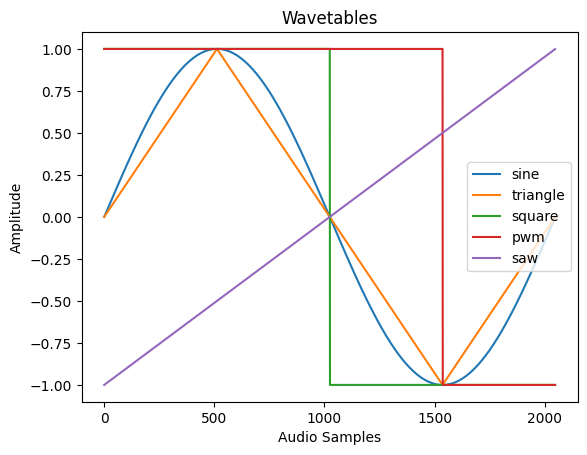

In [23]:
S = 2048  # the length of the wavecycle files we'll create by hand

ramp = np.arange(S)/S

sine = np.sin(ramp*np.pi*2.)

triangle = (1.-2.*abs(abs(np.mod(ramp*2,1.))-.5))*np.where(ramp>0.5, -1, 1)

square = np.where(ramp>0.5, -1, 1)

pwm = np.where(ramp>0.75, -1, 1)

saw = -1+2*ramp

plt.title("Wavetables")
plt.plot(sine, label='sine')
plt.plot(triangle, label='triangle')
plt.plot(square, label='square')
plt.plot(pwm, label='pwm')
plt.plot(saw, label='saw')
plt.legend()
plt.ylabel("Amplitude")
plt.xlabel("Audio Samples")
plt.show()

sine = (sine*np.iinfo(np.int16).max).astype(np.int16)
triangle = (triangle*np.iinfo(np.int16).max).astype(np.int16)
square = (square*np.iinfo(np.int16).max).astype(np.int16)
pwm = (pwm*np.iinfo(np.int16).max).astype(np.int16)
saw = (saw*np.iinfo(np.int16).max).astype(np.int16)

# Save them as wav files.
wavfile.write("sine.wav", 44100, sine)
wavfile.write("triangle.wav", 44100, triangle)
wavfile.write("square.wav", 44100, square)
wavfile.write("pwm.wav", 44100, pwm)
wavfile.write("saw.wav", 44100, saw)

In [24]:
dsp_content = """
import("stdfaust.lib");

// `sf` is a soundfile primitive
wavetable(sf, idx) = it.lagrangeN(N, f_idx, par(i, N + 1, table(i_idx - int(N / 2) + i)))
with {
    N = 3; // lagrange order
    SFC = outputs(sf); // 1 for the length, 1 for the SR, and the remainder are the channels
    S = 0, 0 : sf : ba.selector(0, SFC); // table size
    table(j) = int(ma.modulo(j, S)) : sf(0) : !, !, si.bus(SFC-2);
    f_idx = ma.frac(idx) + int(N / 2);
    i_idx = int(idx);
};

// A user may want to replace this dynamically with a component.
wavetables =
    wavetable(soundfile("param:sine[url:{'sine.wav'}]",1)),
    wavetable(soundfile("param:triangle[url:{'triangle.wav'}]",1)),
    wavetable(soundfile("param:square[url:{'square.wav'}]",1)),
    wavetable(soundfile("param:pwm[url:{'pwm.wav'}]",1)),
    wavetable(soundfile("param:saw[url:{'saw.wav'}]",1));

NUM_TABLES = outputs(wavetables);

// ---------------multiwavetable-----------------------------
// All wavetables are placed evenly apart from each other.
//
// Where:
// * `wt_pos`: wavetable position from [0-1].
// * `ridx`: read index. floating point [0 - (S-1)]
multiwavetable(wt_pos, ridx) = si.vecOp((wavetables_output, coeff), *) :> _
with {
    wavetables_output = ridx <: wavetables;
    // todo: refactor with ef.mixLinearClamp
    coeff = par(i, NUM_TABLES, max(0, 1-abs(i-wt_pos*(NUM_TABLES-1))));
};

S = 2048; // the length of the wavecycles, which we decided elsewhere

wavetable_synth = multiwavetable(wtpos, ridx)*env1*gain
with {
    freq = hslider("freq [style:knob]", 200 , 50  , 1000, .01 );
    gain = hslider("gain [style:knob]", .5  , 0   , 1   , .01 );
    gate = button("gate");

    wtpos = hslider("WT Pos [style:knob]", 0   , 0    , 1   ,  .01);

    ridx = os.hsp_phasor(S, freq, ba.impulsify(gate), 0);
    env1 = en.adsr(.01, 0, 1, .1, gate);
};

replace = !,_;
process = ["freq":replace, "gain":replace, "gate":replace -> wavetable_synth];
"""

with FaustContext():

    DSP_DIR1 = str(Path(os.getcwd()))
    argv = ['-I', DSP_DIR1]
    box = boxFromDSP(dsp_content, argv)
    module_name = 'FaustVoice'
    jax_code = boxToSource(box, 'jax', module_name, ['-a', 'jax/minimal.py'])

custom_globals = {}
exec(jax_code, custom_globals)  # security risk!
MonoVoice = custom_globals[module_name]

### Step 2. Use jax.linen.vmap to batch several voices, sharing parameters and PRNG among them.

In [25]:
PolyVoice = nn.vmap(MonoVoice, in_axes=(0, None), variable_axes={'params': None}, split_rngs={'params': False})

### Step 3. Define the FX module (stereo panner)

In [26]:
dsp_content = """
import("stdfaust.lib");
pan = hslider("pan", 0.5, 0, 1, .01);
process = sp.panner(pan);
"""

with FaustContext():
    
    box = boxFromDSP(dsp_content)
    module_name = 'FaustFX'
    jax_code = boxToSource(box, 'jax', module_name, ['-a', 'jax/minimal.py'])

custom_globals = {}
exec(jax_code, custom_globals)  # security risk!
FaustFX = custom_globals[module_name]

### Step 4. Create an Instrument module that calls the voice batch, sums them, and passes it to the FX module.

In [27]:
soundfile_dirs = [str(Path(os.getcwd()))]

import dataclasses

class PolyInstrument(nn.Module):

    sample_rate: int
    soundfile_dirs: list[str] = dataclasses.field(default_factory=list)

    @nn.compact
    def __call__(self, x, T: int) -> jnp.array:

        # Note that we don't have to think about batches here because we will later call vmap.

        polyvoices = PolyVoice(sample_rate=self.sample_rate, soundfile_dirs=self.soundfile_dirs)

        # audio is shaped (Voices, Channels, Samples)
        audio = polyvoices(x, T)

        # sum all the voices together
        audio = jnp.sum(audio, axis=0)
        # audio is now shaped (Channels, Samples)

        fx = FaustFX(sample_rate=self.sample_rate)

        # apply FX
        audio = fx(audio, T)
        
        return audio

### Step 5. Use jax.linen.vmap to batch the instrument class without sharing parameters or PRNG.

In [28]:
SAMPLE_RATE = 44100
BatchedInstrument = nn.vmap(PolyInstrument, in_axes=(0, None), variable_axes={'params': 0}, split_rngs={'params': True})
batched_model = BatchedInstrument(SAMPLE_RATE, soundfile_dirs)
jit_batched_inference = jax.jit(partial(batched_model.apply, mutable='intermediates'), static_argnums=[2])

### Step 6. Pass a batched tensor of freq/gain/gate and a batch of parameters to the batched Instrument.

In [29]:
T = int(SAMPLE_RATE*2.)

def pitch_to_hz(pitch):
    return 440.0*(2.0**((pitch - 69)/12.0))

def pitch_to_tensor(pitch, gain, note_dur, total_dur):
    # Return 2D tensor shaped (3, total_dur) where
    # 1st dimension is (freq, gain, gate)
    # and 2nd dimension is audio sample
    freq = pitch_to_hz(pitch)
    tensor = jnp.zeros((3, total_dur))
    tensor = tensor.at[:2, :].set(
        jnp.array([freq, gain]).reshape(2, 1))
    tensor = tensor.at[2, :note_dur].set(jnp.array([1]))

    # We could stack multiple notes on this dimension if we wanted to.
    tensor = jnp.expand_dims(tensor, axis=0)
    return tensor

input_tensor = jnp.stack([
    pitch_to_tensor(60, 1, int(SAMPLE_RATE*1.), T),
    pitch_to_tensor(62, 1, int(SAMPLE_RATE*1.), T),
    pitch_to_tensor(64, 1, int(SAMPLE_RATE*1.), T),
    pitch_to_tensor(65, 1, int(SAMPLE_RATE*1.), T),
    pitch_to_tensor(67, 1, int(SAMPLE_RATE*1.), T),
], axis=0)

print(input_tensor.shape)
BATCH_SIZE = input_tensor.shape[0]
# (Batch, polyphony voices, (freq/gain/gate), samples)

(5, 1, 3, 88200)


Above, note that the number of polyphony voices is only 1. We'll try more later.

In [30]:
key, subkey = random.split(key)
params = batched_model.init({'params': subkey}, input_tensor, T)['params']
params

{'FaustFX_0': {'_dawdreamer/pan': Array([0., 0., 0., 0., 0.], dtype=float32)},
 'VmapFaustVoice_0': {'_dawdreamer/WT Pos': Array([-1., -1., -1., -1., -1.], dtype=float32),
  '_dawdreamer/pwm': Array([[[ 0.9999695,  0.9999695,  0.9999695, ..., -0.9999695,
           -0.9999695, -0.9999695]],
  
         [[ 0.9999695,  0.9999695,  0.9999695, ..., -0.9999695,
           -0.9999695, -0.9999695]],
  
         [[ 0.9999695,  0.9999695,  0.9999695, ..., -0.9999695,
           -0.9999695, -0.9999695]],
  
         [[ 0.9999695,  0.9999695,  0.9999695, ..., -0.9999695,
           -0.9999695, -0.9999695]],
  
         [[ 0.9999695,  0.9999695,  0.9999695, ..., -0.9999695,
           -0.9999695, -0.9999695]]], dtype=float32),
  '_dawdreamer/saw': Array([[[-0.9999695 , -0.9989929 , -0.99801636, ...,  0.9970398 ,
            0.99801636,  0.9989929 ]],
  
         [[-0.9999695 , -0.9989929 , -0.99801636, ...,  0.9970398 ,
            0.99801636,  0.9989929 ]],
  
         [[-0.9999695 , -0.9989929 ,

Note that the "WT Pos" parameter was initialized to [-1., -1., -1., -1., -1.]. This means all items in the batch will play the same wavetable. Instead, let's evenly distribute those parameters between -1 and 1. Then we will render the audio.

In [31]:
params['VmapFaustVoice_0']['_dawdreamer/WT Pos'] = jnp.linspace(-1,1,num=BATCH_SIZE)

audio, mod_vars = jit_batched_inference({'params': params}, input_tensor, T)

Now we can listen to the audio. Each item should be a different pitch with a different wavetable, which we confirm by plotting a small time slice.

audio shape:  (5, 2, 88200)


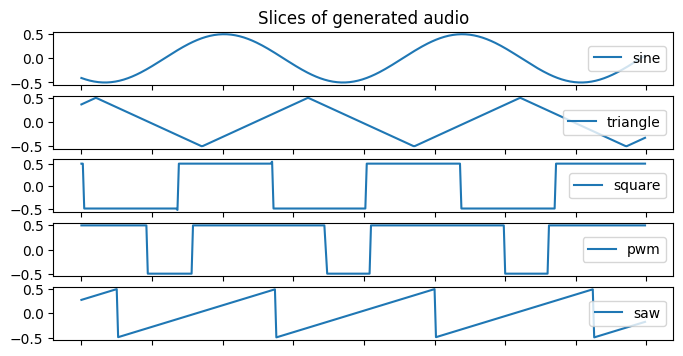

In [32]:
print('audio shape: ', audio.shape)

for item in audio:
    show_audio(item)

plt.figure(figsize =(8, 4))

# plt.title("Slice of generated audio")
for i, item in enumerate(audio):
    wavetable_name = ['sine','triangle','square','pwm','saw'][i]

    ax1 = plt.subplot(5, 1, i+1)
    # selected a region where the envelope is at peak sustain
    data = item[0,20000:20400]
    ax1.plot(data, label=wavetable_name)
    if i == 0:
        ax1.set_title("Slices of generated audio")
    plt.tick_params('x', labelbottom = i == len(wavetable_name)-1)
    
    plt.legend(loc='right')

plt.show()

In [33]:
# Measure speed performance.
%timeit jit_batched_inference({'params': params}, input_tensor, T)

11 ms ± 60 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Now let's pick random wavetable positions, render audio and plot.

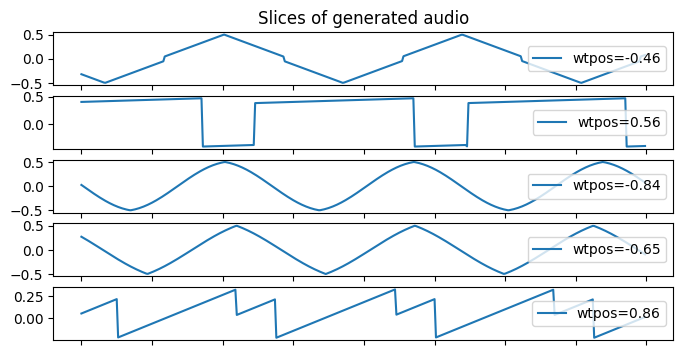

In [34]:
key, subkey = random.split(key)
wt_pos = random.uniform(subkey, shape=(BATCH_SIZE,), minval=-1, maxval=1)
params['VmapFaustVoice_0']['_dawdreamer/WT Pos'] = wt_pos
wt_pos = np.array(wt_pos)

audio, mod_vars = jit_batched_inference({'params': params}, input_tensor, T)

for item in audio:
    show_audio(item)

plt.figure(figsize =(8, 4))

# plt.title("Slice of generated audio")
for i, item in enumerate(audio):
    wavetable_name = f"wtpos={wt_pos[i]:.2f}"

    ax1 = plt.subplot(5, 1, i+1)
    # selected a region where the envelope is at peak sustain
    data = item[0,20000:20400]
    ax1.plot(data, label=wavetable_name)
    if i == 0:
        ax1.set_title("Slices of generated audio")
    plt.tick_params('x', labelbottom = i == len(wavetable_name)-1)
    
    plt.legend(loc='right')

plt.show()

We didn't demonstrate polyphony yet. I just wanted to show how playing one note results in the correct wavecycles. Let's modify our `input_tensor` to have more notes.

In [35]:
print('old input_tensor shape:', input_tensor.shape)

# Cmaj7 chord
chord = jnp.concatenate([
    pitch_to_tensor(60, 1, int(SAMPLE_RATE*1.), T),
    pitch_to_tensor(64, 1, int(SAMPLE_RATE*1.), T),
    pitch_to_tensor(67, 1, int(SAMPLE_RATE*1.), T),
    pitch_to_tensor(71, 1, int(SAMPLE_RATE*1.), T),
], axis=0)

new_tensor = jnp.tile(chord, (5, 1, 1, 1))

print('new_tensor shape:', new_tensor.shape)

audio, mod_vars = jit_batched_inference({'params': params}, new_tensor, T)

for item in audio:
    show_audio(item)

old input_tensor shape: (5, 1, 3, 88200)
new_tensor shape: (5, 4, 3, 88200)


## Caveats

### Gradients (Vanishing and Exploding)

When Faust is converted to JAX, the generated `tick` function is sequential; one sample is generated at a time. This means that when the gradients are unrolled, one sample is also unrolled at a time, making backpropagation potentially slow. Relying on long sequences also makes the modules vulnerable to vanishing and exploding gradients.

### Gradients can be zero

Unfortunately there are many reasons gradients could be zero:
* The DSP can involve discrete choices such as the choice between wavetables without interpolation
* Suppose the audio contains no frequencies above 10 kHz, and a learnable lowpass cutoff frequency is initialized at 15 kHz. With a spectrogram loss, the cutoff will have zero gradient.
* Consider compressors which have a threshold parameter. If the audio doesn't reach the threshold volume, then the compressor's other parameters such as attack and release will have zero gradients.
* Many other complex interactions like the previous examples...

### Pre-computed tables

Some Faust Library functions pre-compute lookup tables for commonly used functions such as `sine`/`cosine`. In the worst case the lookup could occur with no interpolation between two lookup locations, leading to a gradient of zero. Even with interpolation, it might just be linear interpolation, which is imprecise compared to the perfect analytical gradient. If possible, you should use Faust code that is analytically differentiable rather than something involving a pre-computed table.

For example, instead of using `os.osc`, use `sineOsc`:

```faust
import("stdfaust.lib");
sineOsc = phasor : sin
with {
    decimalPart(x) = x-int(x);
    phasor(f) = f/ma.SR : (+ : decimalPart) ~ _;
};
process = sineOsc(440.);
```

To make sure the generated JAX code doesn't have a pre-computed table, you should read the generated `initialize` function and make sure it doesn't have a conspicuous for-loop which writes values into an array.

### Time-varying Delays

Differentiation might not work well with variable-length delays and table lookups. A variable-length delay is essentially a linear interpolation between two samples (Faust does support fancier [interpolators](https://faustlibraries.grame.fr/libs/interpolators/)). Future research should investigate the robustness of algorithms which involve time-varying delays.

### Differentiable IIR Filters

Our generated JAX functions apply reverb and convolutions in the time-domain rather than the frequency-domain. This means the forward pass and backward pass will be slower than if the effects had been calculated in the frequency-domain. This [Intro to DDSP](https://intro2ddsp.github.io/filters/iir_impl.html#custom-backward-functions) explains how PyTorch implemented a custom backward pass in order for the backward pass to be convolutional. Similar work could be done with [XLA](https://www.tensorflow.org/xla) and Faust to automatically generate more optimized backward passes.

### Loss Function

Using a frequency-domain loss function (or any non-time-domain function) is possible, but it doesn't alleviate the computational speed problems outlined above. In fact, it will almost certainly be slower. However, it may lead to more useful gradients.

# Future Research Directions

## Exporting to C++ and other Backends

We've demonstrated how to convert Faust code into several target languages such as C++ and Python JAX. The generated JAX code can be trained, and optimal parameters can be found. We still need an automated system to bring those parameters back to Faust so that Faust can re-target them to another language such as C++. If the number of parameters is small like the toy problems we've shown, it's not a problem to do this by hand, but for larger DSP systems resembling neural networks, it deserves to be automated.

## Differentiable Digital Signal Processing (DDSP)

[DDSP: Differentiable Digital Signal Processing](https://magenta.tensorflow.org/ddsp) (Engel et al., 2020) advocated for an end-to-end differentiable audio pipeline which many research papers have since adopted. In the diagram below, the Encoder and Decoder are neural networks with learned weights. The green components are latent representations, and yellow components are determinisitic synthesizers and effects. The yellow parts of the diagram can be replaced with JAX code generated with Faust and the expansive [Faust Libraries](https://faustlibraries.grame.fr/).

<center>
<img width="75%" src="https://storage.googleapis.com/ddsp/additive_diagram/ddsp_autoencoder.png"></img>
<p>
<i>DDSP auto-encoder diagram, copyright </i><a href="https://magenta.tensorflow.org/ddsp">Google Magenta</a>
</p>
</center>

In the earlier code for the polyphonic wavetable synth, we used a tensor involving `freq`, `gain`, and `gate`. This tensor could have been generated by a differentiable module unrelated to JAX, just like the green components in the DDSP diagram. It would also be interesting to lift other parameters into audio-rate inputs. For example, a neural network could optimize the entire automation of a filter cutoff. This parameterized input signal could be created at a control-rate (441 Hz). You would use linear-interpolation to upsample it to 44100 Hz, and then stack it onto the `freq`/`gain`/`gate` tensor.

DDSP introduced many differentiable effects including chorus, flanger, vibrato, and two reverbs. Now that Faust connects to JAX, one can use functions from the [Faust Libraries](https://faustlibraries.grame.fr/) in a DDSP-style pipeline. These include emulations of the [Yamaha DX7 synthesizer](https://faustlibraries.grame.fr/libs/dx7/), [physical modeling](https://faustlibraries.grame.fr/libs/physmodels/), [several reverbs](https://faustlibraries.grame.fr/libs/reverbs/), [high-order ambisonics](https://faustlibraries.grame.fr/libs/hoa/), and more.

## RAVE (**R**ealtime **A**udio **V**ariational auto**E**ncoder)

[RAVE](https://github.com/acids-ircam/RAVE) (Caillon et al., 2020) is a model architecture designed for fast, high-quality, and high sample rate audio generation. We believe it would be possible to re-write RAVE's decoder architecture in Faust. The other parts of the model which are currently in PyTorch would need to be re-written in JAX. Then if the model were trained, we would need to automate the process of re-inserting the parameters into Faust code. Then the Faust code could be exported to C++ with no Max/MSP or libtorch dependency and run with extremely low latency (8 samples) on [microcontrollers](https://faustdoc.grame.fr/tutorials/esp32/). [Several researchers](https://team.inria.fr/emeraude/) are already testing Faust with FPGAs (Field Programmable Gate Arrays). We hope RAVE or similar models will eventually be run on an FPGA.

## State-Space Models (SSM)

Besides writing a large portion of the Faust Libraries, [Julius Smith](https://ccrma.stanford.edu/~jos/) has written [Faust code for a digital State-Space Model](https://ccrma.stanford.edu/~jos/aspf/Appendix_A_State_Space_Models.html). Once exported to JAX, this would be a nicely parameterized system for audio effect modeling. Another starter code for neural networks written in Faust is [here](https://github.com/grame-cncm/faust/blob/master-dev/examples/filtering/DNN.dsp).

## Feedback Delay Networks

Julius Smith has also provided useful Faust code for [Feedback Delay Networks](https://ccrma.stanford.edu/~jos/pasp/FDN_Reverberators_Faust.html). By customizing the JAX architecture file ([minimal.py](https://github.com/grame-cncm/faust/blob/master-dev/architecture/jax/minimal.py)), the weights of an FDN can be set via soundfile primitives. This would allow differentiable FDNs as well as massively parallel generation of FDN outputs.

## Yamaha DX-7

There is a starter project for the Yamaha DX7 in JAX: https://github.com/DBraun/DX7-JAX

This project could be used to follow up on research like ["Quality-diversity for Synthesizer Sound Matching"](https://www.jstage.jst.go.jp/article/ipsjjip/31/0/31_220/_article/-char/en) (Masuda & Saito, 2023).

Alternatively, you could replace the DX7 with your own instrument and effects.

## The Faust box API

We've been writing Faust code "manually" and then converting it to JAX. Instead it's possible to use DawDreamer's Python bindings to the Faust box API to create JAX code. For a list of box operators, see the [DawDreamer documentation](https://dirt.design/DawDreamer/_generate/dawdreamer.faust.box.html). For more examples of the box API, check out the box API tutorial: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](http://colab.research.google.com/github/DBraun/DawDreamer/blob/main/examples/Box_API/Faust_Box_API.ipynb)

In [36]:
with FaustContext():
    
    # Create a box representing an input signal (1 input and 1 output).
    box1 = boxWire()

    assert box1.inputs == 1
    assert box1.outputs == 1

    # since box1 has one output, we can perform simple built-in arithmetic operators on it
    box2 = box1 + 0.5
    # alternatively, we could have done
    # box2 = boxAdd(box1, boxReal(0.5))

    # box2 still has 1 input and 1 output.

    box3 = box2 * 1.5
    # box3 still has 1 input and 1 output.

    box4 = boxAtan2(box2, box3)
    # box4 has 2 inputs (because box2 and box3 both have 1 input) and 1 output.

    box5 = boxFromDSP("process = fi.lowpass(2, 10000);")
    # box5 has 1 input and 1 output.

    # box4's outputs (1) == box5's inputs (1), so we can sequence them
    box6 = boxSeq(box4, box5)

    assert box6.inputs == 2
    assert box6.outputs == 1

    jax_code = boxToSource(box6, 'jax', module_name)
    # print(jax_code)

We believe the box and signal APIs open opportunities for program synthesis. It would be interesting to explore the space of potential DSP topologies while also numerically optimizing via JAX.

## Quality-Diversity algorithms

[QDax](https://github.com/adaptive-intelligent-robotics/QDax/) is a library of JAX code for Quality-Diversity algorithms, which are a class of neuro-evolution algorithms. The motivation behind QD is that for some problems, multiple and very different solutions can exist. Therefore, we want algorithms that can adequately explore the parameter space without giving too much preference to one region. Luckily, the Faust to JAX pipeline works with QDax! It's particularly useful when the loss landscape is very deceptive or when backpropagation is still too slow.

Check out the Faust to QDax Colab: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](http://colab.research.google.com/github/DBraun/DawDreamer/blob/main/examples/Faust_to_QDax/Faust_to_QDax.ipynb)